In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
df = pd.read_csv("C:\\Users\\ACER\\Desktop\\Projects\\Machine Learning Based Real Estate System\\Dataset\\Cleaned_Properties_V2.csv")

In [42]:
df.head(3)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,umang winter hills,sector 77,1.00,7500.0,1333.0,Carpet area: 1340 (124.49 sq.m.),2,2,2,...,NaN,NaN,1340.0,0,0,0,0,0,1,74
1,flat,emaar mgf emerald estate,sector 65,1.75,12544.0,1395.0,Super Built up area 1395(129.6 sq.m.)Carpet ar...,3,3,3,...,1395.0,NaN,809.0,0,1,0,0,0,0,124
2,house,suncity township,sector 54,2.00,30968.0,646.0,Plot area 60Built Up area: 60 sq.m.Carpet area...,9,9,3,...,NaN,60.0,59.0,0,1,0,0,0,2,7


In [43]:
df.shape

(3856, 23)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3856 entries, 0 to 3855
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3856 non-null   object 
 1   society              3855 non-null   object 
 2   sector               3856 non-null   object 
 3   price                3838 non-null   float64
 4   price_per_sqft       3838 non-null   float64
 5   area                 3838 non-null   float64
 6   areaWithType         3856 non-null   object 
 7   bedRoom              3856 non-null   int64  
 8   bathroom             3856 non-null   int64  
 9   balcony              3856 non-null   object 
 10  floorNum             3835 non-null   float64
 11  facing               2729 non-null   object 
 12  agePossession        3856 non-null   object 
 13  super_built_up_area  1921 non-null   float64
 14  built_up_area        1777 non-null   float64
 15  carpet_area          1965 non-null   f

In [45]:
df.duplicated().sum()

128

In [46]:
df.drop_duplicates(inplace=True)

In [47]:
df.head(2)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,umang winter hills,sector 77,1.00,7500.0,1333.0,Carpet area: 1340 (124.49 sq.m.),2,2,2,...,NaN,NaN,1340.0,0,0,0,0,0,1,74
1,flat,emaar mgf emerald estate,sector 65,1.75,12544.0,1395.0,Super Built up area 1395(129.6 sq.m.)Carpet ar...,3,3,3,...,1395.0,NaN,809.0,0,1,0,0,0,0,124


### Property Type

<Axes: xlabel='property_type'>

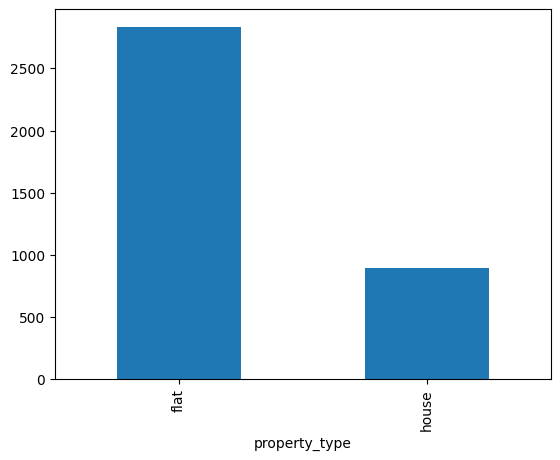

In [48]:
df['property_type'].value_counts().plot(kind='bar')

Observations

- Flats are in majority(75 percent) and there are less number of houses(~25 percent)
- No missing values

### Society

In [49]:
df['society'].value_counts().shape

(688,)

In [50]:
df['society'].value_counts()

society
independent                             517
tulip violet                             75
ss the leaf                              73
dlf new town heights                     42
shapoorji pallonji joyville gurugram     42
                                       ... 
krishna apartment                         1
divya apartments                          1
sobha smriti apartments                   1
navjyoti apartment                        1
shreeram apartment ii                     1
Name: count, Length: 688, dtype: int64

In [51]:
df[df['society'] != 'independent']['society'].value_counts(normalize=True).cumsum().head(75) 

society
tulip violet                            0.023364
ss the leaf                             0.046106
shapoorji pallonji joyville gurugram    0.059190
dlf new town heights                    0.072274
signature global park                   0.083178
                                          ...   
the close north                         0.487227
umang winter hills                      0.491277
ats kocoon                              0.495327
unitech uniworld resorts                0.499065
mvn athens                              0.502804
Name: proportion, Length: 75, dtype: float64

In [52]:
society_counts = df['society'].value_counts()

# Frequency Distribution for Societies
society_frequency_bins = {
    "Very High (> 100)": (society_counts > 100).sum(),
    "High (50 - 100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10 - 49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2 - 9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}
society_frequency_bins

{'Very High (> 100)': 1,
 'High (50 - 100)': 2,
 'Average (10 - 49)': 92,
 'Low (2 - 9)': 279,
 'Very Low (1)': 314}

<Axes: xlabel='society'>

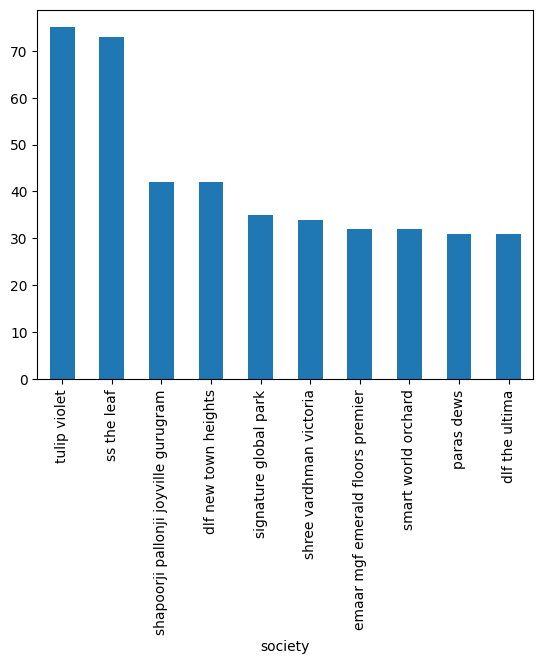

In [53]:
# Top 10 Societies

df[df['society'] != 'independent']['society'].value_counts().head(10).plot(kind='bar')

In [54]:
df['society'].isnull().sum()

1

In [55]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1924,flat,NaN,sector 78,0.6,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,...,NaN,1625.0,NaN,0,0,0,0,0,1,0


Observations

- Around 13% properties comes under independent tag.
- There are 675 societies.
- The top 75 societies have 50 percent of the preperties and the rest 50 percent of the properties come under the remaining 600 societies
    - Very High (>100): Only 1 society has more than 100 listings.
    - High (50-100): 2 societies have between 50 to 100 listings.
    - Average (10-49): 92 societies fall in this range with 10 to 49 listings each.
    - Low (2-9): 273 societies have between 2 to 9 listings.
    - Very Low (1): A significant number, 308 societies, have only 1 listing.
- 1 missing value

### Sector

In [56]:
df['sector'].value_counts().shape

(111,)

<Axes: xlabel='sector'>

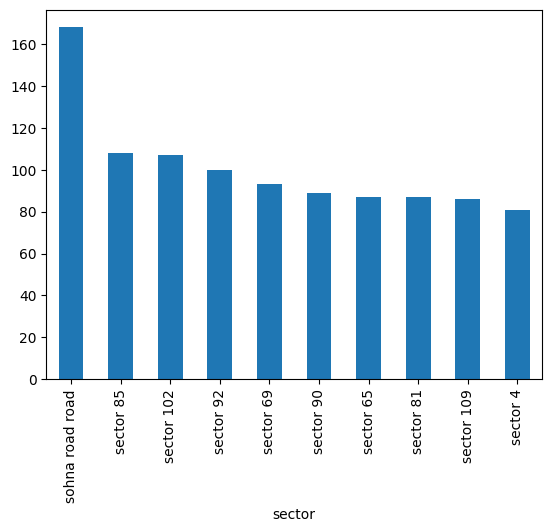

In [57]:
df['sector'].value_counts().head(10).plot(kind='bar')

In [58]:
sector_counts = df['sector'].value_counts()

# Frequency Distribution for Societies
sector_frequency_bins = {
    "Very High (> 100)": (sector_counts > 100).sum(),
    "High (50 - 100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10 - 49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2 - 9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}
sector_frequency_bins

{'Very High (> 100)': 3,
 'High (50 - 100)': 26,
 'Average (10 - 49)': 58,
 'Low (2 - 9)': 23,
 'Very Low (1)': 1}

Observations

- There are a total of 104 unique sectors in the dataset.
- Frequency distribution of sectors:
    - Very High (>100): 3 sectors have more than 100 listings.
    - High (50-100): 25 sectors have between 50 to 100 listings.
    - Average (10-49): A majority, 60 sectors, fall in this range with 10 to 49 listings each.
    - Low (2-9): 16 sectors have between 2 to 9 listings.
    - Very Low (1): Interestingly, there are no sectors with only 1 listing.

### Price

In [59]:
df['price'].isnull().sum()

17

In [60]:
df.price.describe()

count    3711.000000
mean        2.530369
std         2.975435
min         0.070000
25%         0.950000
50%         1.520000
75%         2.750000
max        31.500000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

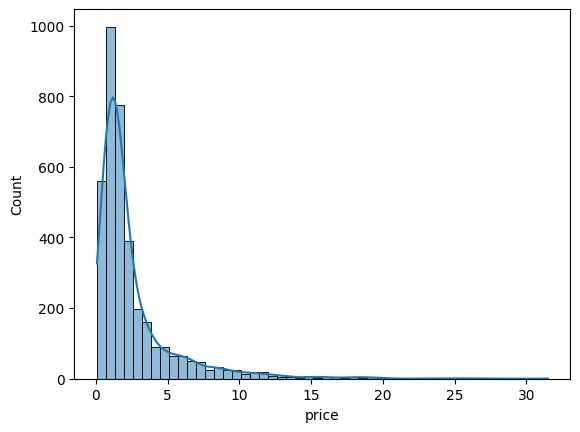

In [61]:
sns.histplot(df['price'], kde=True, bins=50)

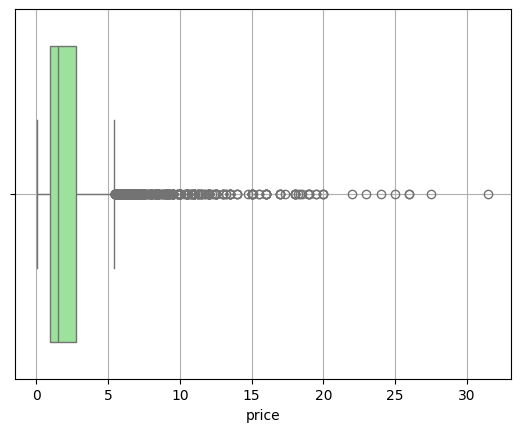

In [62]:
sns.boxplot(x = df['price'], color='lightgreen')
plt.grid()

Descriptive Statistics:

- Count: There are 3,660 non-missing price entries.
- Mean Price: The average price is approximately 2.53 crores.
- Median Price: The median (or 50th percentile) price is 1.52 crores.
- Standard Deviation: The prices have a standard deviation of 2.98, indicating variability in the prices.
- Range: Prices range from a minimum of 0.07 crores to a maximum of 31.5 crores.
- IQR: The interquartile range (difference between 75th and 25th percentile) is from 0.95 crores to 2.75 crores.


Visualizations:

- Distribution: The histogram indicates that most properties are priced in the lower range (below 5 crores), with a few properties going beyond 10 crores.
- Box Plot: The box plot showcases the spread of the data and potential outliers. Properties priced above approximately 10 crores might be considered outliers as they lie beyond the upper whisker of the box plot.


Missing Values: There are 17 missing values in the price column.

In [63]:
# Skewness and Kurtosis

skewness = df['price'].skew()
kurtosis = df['price'].kurt()

print(skewness, kurtosis)

3.2802577708409024 14.942253563662078


<b>Skewness:</b> The price distribution has a skewness of approximately 3.28, indicating a positive skew. This means that the distribution tail is skewed to the right, which aligns with our observation from the histogram where most properties have prices on the lower end with a few high-priced properties.

<b>Kurtosis:</b> The kurtosis value is approximately 14.93. A kurtosis value greater than 3 indicates a distribution with heavier tails and more outliers compared to a normal distribution.

In [64]:
# Quantile Analysis
quantiles = df['price'].quantile([0.01, 0.05, 0.95, 0.99])

quantiles

0.01     0.25
0.05     0.37
0.95     8.50
0.99    15.46
Name: price, dtype: float64